In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import seaborn as sns
import scanpy as sc
import muon as mu
import builtins #this is because np is shadowing built in sum but can be overwritten using builtins

mpl.rcParams.update({
    # --- Fonts: keep text editable ---
    'pdf.fonttype': 'truetype',   # same as 42, ensures TrueType fonts
    'ps.fonttype': 'truetype',    # for EPS compatibility
    'svg.fonttype': 'none',       # keeps SVG text as text, not outlines

    # --- General style niceties ---
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.family': 'sans-serif'
})

from IPython.display import display, HTML
display(HTML("<style>.jp-Cell { margin-left: -20% !important; margin-right: -15% !important; }</style>"))

In [2]:
#Variable, settings, colors

In [3]:
#colors
colors_sheet = pd.read_excel('../data/production_color_v1.xlsx') #test sheet

#make leiden cluster color dictionary
colors_dict = dict(zip(colors_sheet.leiden, colors_sheet.colour))

# #Create colour sub dictionaries for UMAPS _ healthy
# geno = ['mt', 'wt','unknown']
# cd_geno = {}
# for k in colors_dict.keys():
#     if k in geno:
#         cd_geno[str(k)] = colors_dict[k]

In [4]:
lclusters = ['2','6','17','21','5','16','12', '1','11','24','4','0','19','3', '10', '7','15','23','18',  '14', '8', '20', '22', '13','9'] #ordered cluster list
lclusters_int = [int(i) for i in lclusters]

In [5]:
#Markers used for each patient
plot_order = {'P18': ['ADT.CD45RA', 'ADT.CD7', 'ADT.CD56', 'ADT.CD36', 'ADT.CD40'],
            'P17': ['ADT.CD31', 'ADT.CD49b', 'ADT.GPR56', 'ADT.CD34', 'ADT.CD71'],
            'P03': ['ADT.CD45RA', 'ADT.CD34', 'ADT.CD49b', 'ADT.GPR56', 'ADT.CD71']}

In [6]:
# Read in CITEseq data
mdata = mu.read_h5ad('../Data/GEO_data_file_v1.h5mu', mod = 'protein')
mdata.var_names_make_unique()
mdata

AnnData object with n_obs × n_vars = 33853 × 272
    obs: 'capture_pool', 'patient_alias', 'time', 'leiden'
    layers: 'counts'

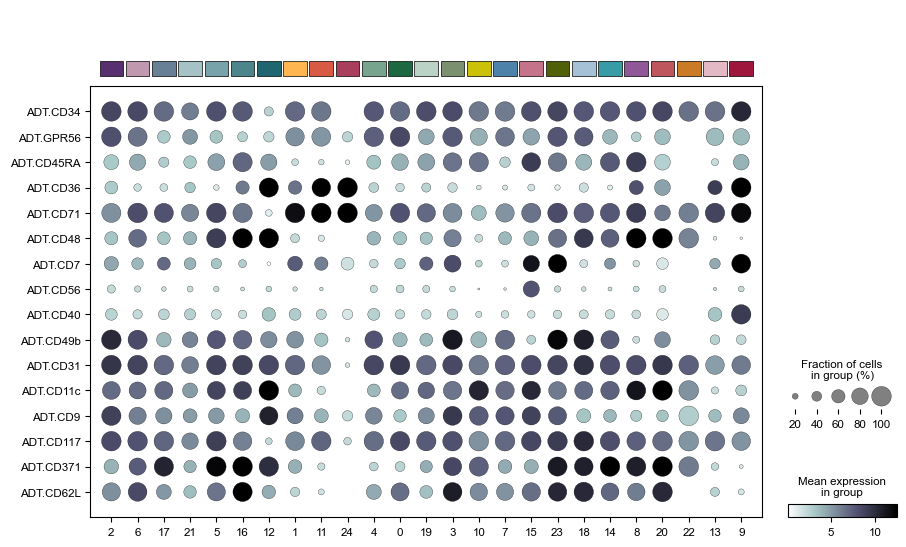

In [7]:
# Make a dotplot which shows the percentage of all cells positive atypical cluster defining markers

# Define the antibody markers to plot
markers = ['ADT.CD34',
            'ADT.GPR56',
            'ADT.CD45RA',   
            'ADT.CD36',
            'ADT.CD71',
            'ADT.CD48',
            'ADT.CD7',
            'ADT.CD56',
            'ADT.CD40',
            'ADT.CD49b',
            'ADT.CD31',
            'ADT.CD11c',
            'ADT.CD9',
            'ADT.CD117',
            'ADT.CD371',
            'ADT.CD62L'] #Revise order to match healthyier markers

mdata_filtered = mdata[mdata.obs['leiden'].isin(lclusters)]

cmap = sns.color_palette("bone_r", as_cmap=True)

# Create dotplot (no fig/ax passed)
dot = sc.pl.dotplot(
    mdata_filtered,
    var_names=markers,
    groupby='leiden',
    categories_order=lclusters,
    cmap=cmap,
    expression_cutoff=2.5,
    vmax=12.5,
    swap_axes=True,
    show=False
)

# --- Handle both return types ---
if isinstance(dot, dict):
    axes = dot
    main_ax = axes.get('mainplot_ax', None)
    if main_ax is None:
        raise KeyError("Couldn't find 'mainplot_ax' in axes dict.")
    fig = main_ax.figure
else:
    axes = dot.get_axes()
    main_ax = axes['mainplot_ax']
    fig = main_ax.figure

# --- Rotate x tick labels ---
main_ax.set_xticklabels(main_ax.get_xticklabels(), rotation=0, ha='center')

# --- Get tick info ---
xticks = main_ax.get_xticks()
xticklabels = [t.get_text() for t in main_ax.get_xticklabels()]

# --- Add color squares above top row ---
ymin, ymax = main_ax.get_ylim()
square_y = ymax -1
square_size = 0.9

for x, label in zip(xticks, xticklabels):
    color = colors_dict.get(int(label), 'lightgrey')
    rect = mpatches.Rectangle(
        (x - square_size / 2, square_y),
        width=square_size,
        height=square_size/1.5,
        facecolor=color,
        edgecolor='k',
        lw=0.5,
        zorder=15,
        clip_on=False,
        transform=main_ax.transData
    )
    main_ax.add_patch(rect)

# --- Expand limits and figure space ---
fig.subplots_adjust(top=0.92, bottom=0.15, left=0.2, right=0.95)

#fig.savefig('../Figures/1_ADT_dotplot_leiden_clusters_healthy_markers_v2_GEO.pdf', dpi=600, bbox_inches=None, format = 'pdf')

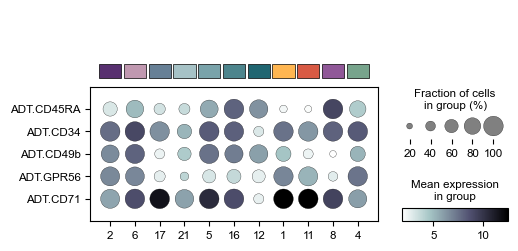

In [8]:
# Make a dotplot which shows the percentage of all cells positive atypical cluster defining markers - P03

# Define the antibody markers to plot
markers = plot_order['P03']

p3_clusters = ['2','6','17','21','5','16','12', '1','11','24', '8', '4']

mdata_filtered = mdata[mdata.obs['leiden'].isin(p3_clusters) & mdata.obs['patient_alias'].isin(['P03'])]

plot_clusters = [c for c in p3_clusters if c in mdata_filtered.obs['leiden'].drop_duplicates().to_list()]

cmap = sns.color_palette("bone_r", as_cmap=True)

# Create dotplot (no fig/ax passed)
dot = sc.pl.dotplot(
    mdata_filtered,
    var_names=markers,
    groupby='leiden',
    categories_order=plot_clusters,
    cmap=cmap,
    expression_cutoff=2.5,
    vmax=12.5,
    swap_axes=True,
    show=False
)

# --- Handle both return types ---
if isinstance(dot, dict):
    axes = dot
    main_ax = axes.get('mainplot_ax', None)
    if main_ax is None:
        raise KeyError("Couldn't find 'mainplot_ax' in axes dict.")
    fig = main_ax.figure
else:
    axes = dot.get_axes()
    main_ax = axes['mainplot_ax']
    fig = main_ax.figure

# --- Rotate x tick labels ---
main_ax.set_xticklabels(main_ax.get_xticklabels(), rotation=0, ha='center')

# --- Get tick info ---
xticks = main_ax.get_xticks()
xticklabels = [t.get_text() for t in main_ax.get_xticklabels()]

# --- Add color squares above top row ---
ymin, ymax = main_ax.get_ylim()
square_y = ymax -1
square_size = 0.9

for x, label in zip(xticks, xticklabels):
    color = colors_dict.get(int(label), 'lightgrey')
    rect = mpatches.Rectangle(
        (x - square_size / 2, square_y),
        width=square_size,
        height=square_size/1.5,
        facecolor=color,
        edgecolor='k',
        lw=0.5,
        zorder=15,
        clip_on=False,
        transform=main_ax.transData
    )
    main_ax.add_patch(rect)

# --- Expand limits and figure space ---
fig.subplots_adjust(top=0.92, bottom=0.15, left=0.2, right=0.95)

#fig.savefig('../Figures/4_ADT_dotplot_leiden_clusters_P03_sorts_GEO.pdf', dpi=600, bbox_inches=None, format = 'pdf')

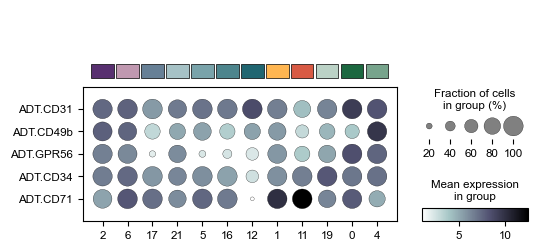

In [9]:
# Make a dotplot which shows the percentage of all cells positive atypical cluster defining markers - P17

# Define the antibody markers to plot
markers = plot_order['P17']

p17_clusters = ['2','6','17','21','5','16','12', '1','11','24',  '19', '0','4']

mdata_filtered = mdata[mdata.obs['leiden'].isin(p17_clusters) & mdata.obs['patient_alias'].isin(['P17'])]

plot_clusters = [c for c in p17_clusters if c in mdata_filtered.obs['leiden'].drop_duplicates().to_list()]

cmap = sns.color_palette("bone_r", as_cmap=True)

# Create dotplot (no fig/ax passed)
dot = sc.pl.dotplot(
    mdata_filtered,
    var_names=markers,
    groupby='leiden',
    categories_order=plot_clusters,
    cmap=cmap,
    expression_cutoff=2.5,
    vmax=12.5,
    swap_axes=True,
    show=False
)

# --- Handle both return types ---
if isinstance(dot, dict):
    axes = dot
    main_ax = axes.get('mainplot_ax', None)
    if main_ax is None:
        raise KeyError("Couldn't find 'mainplot_ax' in axes dict.")
    fig = main_ax.figure
else:
    axes = dot.get_axes()
    main_ax = axes['mainplot_ax']
    fig = main_ax.figure

# --- Rotate x tick labels ---
main_ax.set_xticklabels(main_ax.get_xticklabels(), rotation=0, ha='center')

# --- Get tick info ---
xticks = main_ax.get_xticks()
xticklabels = [t.get_text() for t in main_ax.get_xticklabels()]

# --- Add color squares above top row ---
ymin, ymax = main_ax.get_ylim()
square_y = ymax -1
square_size = 0.9

for x, label in zip(xticks, xticklabels):
    color = colors_dict.get(int(label), 'lightgrey')
    rect = mpatches.Rectangle(
        (x - square_size / 2, square_y),
        width=square_size,
        height=square_size/1.5,
        facecolor=color,
        edgecolor='k',
        lw=0.5,
        zorder=15,
        clip_on=False,
        transform=main_ax.transData
    )
    main_ax.add_patch(rect)

# --- Expand limits and figure space ---
fig.subplots_adjust(top=0.92, bottom=0.15, left=0.2, right=0.95)

#fig.savefig('../Figures/4_ADT_dotplot_leiden_clusters_P17_sorts_GEO.pdf', dpi=600, bbox_inches=None, format = 'pdf')

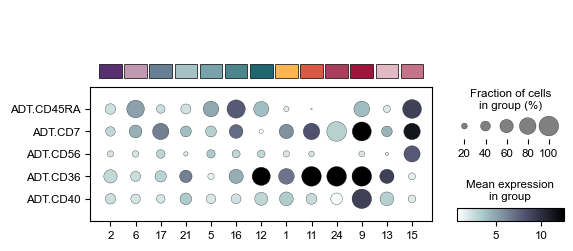

In [10]:
# Make a dotplot which shows the percentage of all cells positive atypical cluster defining markers - P18

# Define the antibody markers to plot
markers = plot_order['P18']

p18_clusters = ['2','6','17','21','5','16','12', '1','11','24',  '9', '13','15']

mdata_filtered = mdata[mdata.obs['leiden'].isin(p18_clusters) & mdata.obs['patient_alias'].isin(['P18'])]

plot_clusters = [c for c in p18_clusters if c in mdata_filtered.obs['leiden'].drop_duplicates().to_list()]

cmap = sns.color_palette("bone_r", as_cmap=True)

# Create dotplot (no fig/ax passed)
dot = sc.pl.dotplot(
    mdata_filtered,
    var_names=markers,
    groupby='leiden',
    categories_order=plot_clusters,
    cmap=cmap,
    expression_cutoff=2.5,
    vmax=12.5,
    swap_axes=True,
    show=False
)

# --- Handle both return types ---
if isinstance(dot, dict):
    axes = dot
    main_ax = axes.get('mainplot_ax', None)
    if main_ax is None:
        raise KeyError("Couldn't find 'mainplot_ax' in axes dict.")
    fig = main_ax.figure
else:
    axes = dot.get_axes()
    main_ax = axes['mainplot_ax']
    fig = main_ax.figure

# --- Rotate x tick labels ---
main_ax.set_xticklabels(main_ax.get_xticklabels(), rotation=0, ha='center')

# --- Get tick info ---
xticks = main_ax.get_xticks()
xticklabels = [t.get_text() for t in main_ax.get_xticklabels()]

# --- Add color squares above top row ---
ymin, ymax = main_ax.get_ylim()
square_y = ymax -1
square_size = 0.9

for x, label in zip(xticks, xticklabels):
    color = colors_dict.get(int(label), 'lightgrey')
    rect = mpatches.Rectangle(
        (x - square_size / 2, square_y),
        width=square_size,
        height=square_size/1.5,
        facecolor=color,
        edgecolor='k',
        lw=0.5,
        zorder=15,
        clip_on=False,
        transform=main_ax.transData
    )
    main_ax.add_patch(rect)

# --- Expand limits and figure space ---
fig.subplots_adjust(top=0.92, bottom=0.15, left=0.2, right=0.95)

#fig.savefig('../Figures/4_ADT_dotplot_leiden_clusters_P18_sorts_GEO.pdf', dpi=600, bbox_inches=None, format = 'pdf')